In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("loan_approval_data.csv")

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_ID        950 non-null    float64
 1   Applicant_Income    950 non-null    float64
 2   Coapplicant_Income  950 non-null    float64
 3   Employment_Status   950 non-null    object 
 4   Age                 950 non-null    float64
 5   Marital_Status      950 non-null    object 
 6   Dependents          950 non-null    float64
 7   Credit_Score        950 non-null    float64
 8   Existing_Loans      950 non-null    float64
 9   DTI_Ratio           950 non-null    float64
 10  Savings             950 non-null    float64
 11  Collateral_Value    950 non-null    float64
 12  Loan_Amount         950 non-null    float64
 13  Loan_Term           950 non-null    float64
 14  Loan_Purpose        950 non-null    object 
 15  Property_Area       950 non-null    object 
 16  Educati

In [4]:
df.head()

,Applicant_ID,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,1.0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2.0,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,NaN,Car,Semiurban,Graduate,NaN,Private,No
2,3.0,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,NaN,Urban,NaN,Female,Government,Yes
3,4.0,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,5.0,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,NaN,Graduate,Male,Private,Yes


In [5]:
df.describe()

,Applicant_ID,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term
count,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000
mean,501.220000,10852.571579,5082.455789,39.971579,1.474737,676.033684,1.950526,0.347263,9940.452632,24802.792632,20522.825263,48.000000
std,289.608451,5061.632859,2943.161570,11.139797,1.105067,71.346015,1.406246,0.144341,5860.736885,14345.696031,11504.142575,24.245322
min,1.000000,2009.000000,1.000000,21.000000,0.000000,550.000000,0.000000,0.100000,65.000000,36.000000,1015.000000,12.000000
25%,250.250000,6730.750000,2472.750000,30.250000,1.000000,616.250000,1.000000,0.220000,4760.250000,12698.250000,9806.250000,24.000000
50%,499.500000,10548.000000,5205.500000,40.000000,1.000000,678.000000,2.000000,0.340000,9880.500000,24321.000000,21210.500000,48.000000
75%,752.750000,15190.000000,7620.750000,49.000000,2.000000,737.000000,3.000000,0.480000,15074.500000,36947.000000,30263.000000,72.000000
max,1000.000000,19988.000000,9996.000000,59.000000,3.000000,799.000000,4.000000,0.600000,19996.000000,49954.000000,39995.000000,84.000000


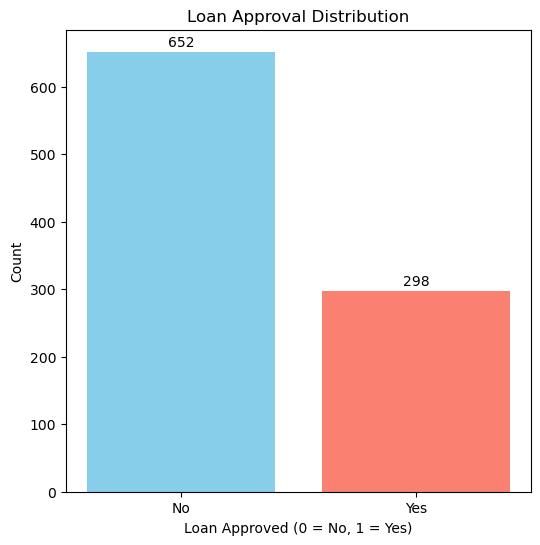

In [6]:
#No.of loans are approved / rejecetd

import matplotlib.pyplot as plt

loan_counts = df["Loan_Approved"].value_counts() # gets count of no.of occurences of 0's / 1's

plt.figure(figsize=(6,6))
plt.bar(loan_counts.index.astype(str), 
        loan_counts.values, 
        color=['skyblue', 'salmon'])

plt.title("Loan Approval Distribution")
plt.xlabel("Loan Approved (0 = No, 1 = Yes)")
plt.ylabel("Count")

for i in range(0,2):
    plt.text(i,loan_counts.values[i]+ 8,str(loan_counts.values[i]),ha='center')

In [7]:
df.duplicated().sum()  # No duplicate values

np.int64(0)

# Handle Missing Values

In [8]:
 # Missing Values  (50 Values are missing in each feature)
df.isnull().sum()

Applicant_ID          50
Applicant_Income      50
Coapplicant_Income    50
Employment_Status     50
Age                   50
Marital_Status        50
Dependents            50
Credit_Score          50
Existing_Loans        50
DTI_Ratio             50
Savings               50
Collateral_Value      50
Loan_Amount           50
Loan_Term             50
Loan_Purpose          50
Property_Area         50
Education_Level       50
Gender                50
Employer_Category     50
Loan_Approved         50
dtype: int64

<Axes: >

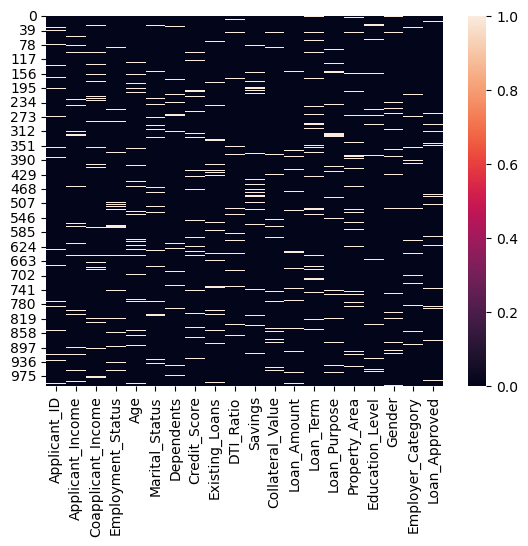

In [9]:
import seaborn as sns
sns.heatmap(df.isnull())  # How null values are there eg: form of chunks or randomly throughout the data

In [10]:
# Drop rows if the Applicant_ID or Loan_Approved status is missing bcoz filling applicant_id with any strategy becomes meaningless for that applicant
# (if Strategy = mean) -> ex:- 45.6,53.2 -----Meaningless
#(if Strategy = most-frequent) ->applicants with same applicant_id-----Meaningless


# So we drop rows with no applicant_id or no loan_approved status

df.dropna(subset=['Applicant_ID', 'Loan_Approved'], inplace=True) # deletion in original df

# Check your missing values again
print(df.isnull().sum())

Applicant_ID           0
Applicant_Income      44
Coapplicant_Income    45
Employment_Status     44
Age                   42
Marital_Status        46
Dependents            46
Credit_Score          46
Existing_Loans        47
DTI_Ratio             45
Savings               48
Collateral_Value      48
Loan_Amount           46
Loan_Term             46
Loan_Purpose          48
Property_Area         47
Education_Level       46
Gender                45
Employer_Category     41
Loan_Approved          0
dtype: int64


# EDA

Text(0.5, 1.0, 'Is Loan approved or not?')

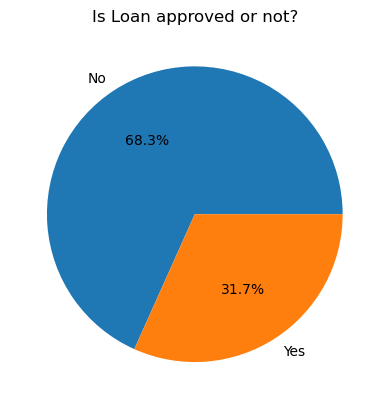

In [11]:
# how balanced our classes are?

classes_count = df["Loan_Approved"].value_counts()

plt.pie(classes_count, labels=["No", "Yes"], autopct="%1.1f%%")
plt.title("Is Loan approved or not?")

[Text(0, 0, '513'), Text(0, 0, '344')]

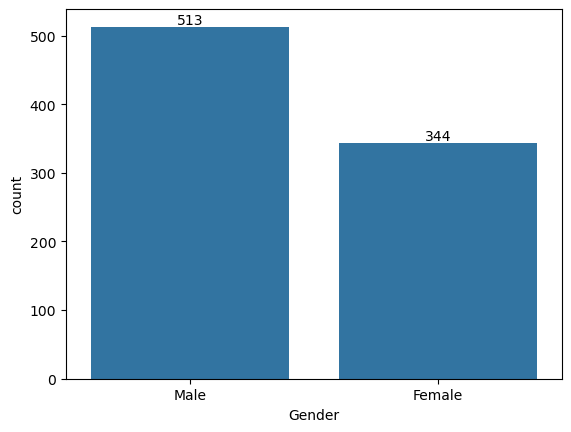

In [12]:
# analyze categories based on Gender
import seaborn as sns
gender_cnt = df["Gender"].value_counts()  # More no.of.males
ax = sns.barplot(gender_cnt)
ax.bar_label(ax.containers[0])


[Text(0, 0, '604'), Text(0, 0, '252')]

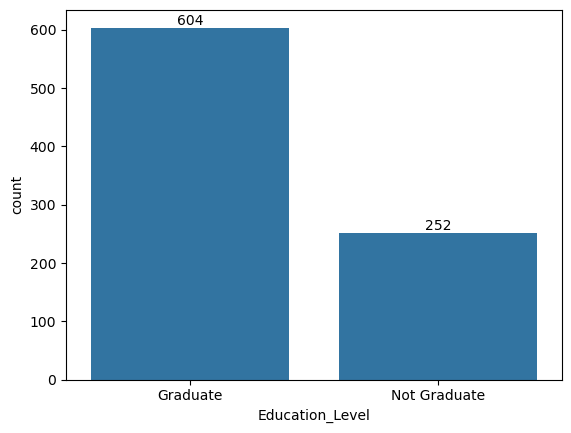

In [13]:
# based on Education_level
edu_cnt = df["Education_Level"].value_counts()
ax = sns.barplot(edu_cnt)
ax.bar_label(ax.containers[0])

<Axes: xlabel='Applicant_Income', ylabel='Count'>

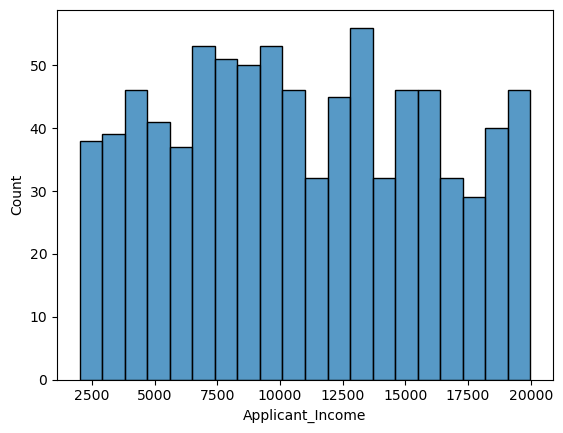

In [14]:
# analyze income

sns.histplot(
    data = df,
    x = "Applicant_Income",
    bins=20
)

<Axes: xlabel='Coapplicant_Income', ylabel='Count'>

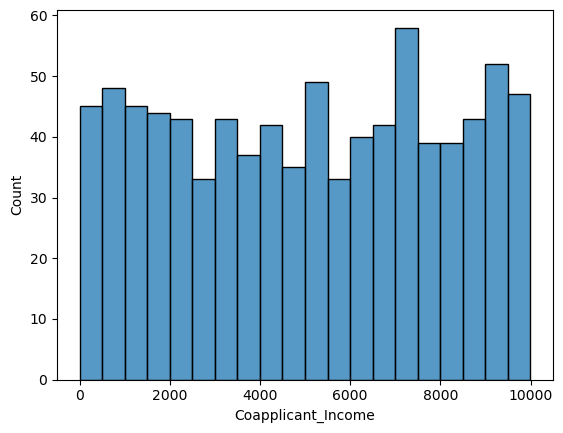

In [15]:
sns.histplot(
    data = df,
    x = "Coapplicant_Income",
    bins=20
)

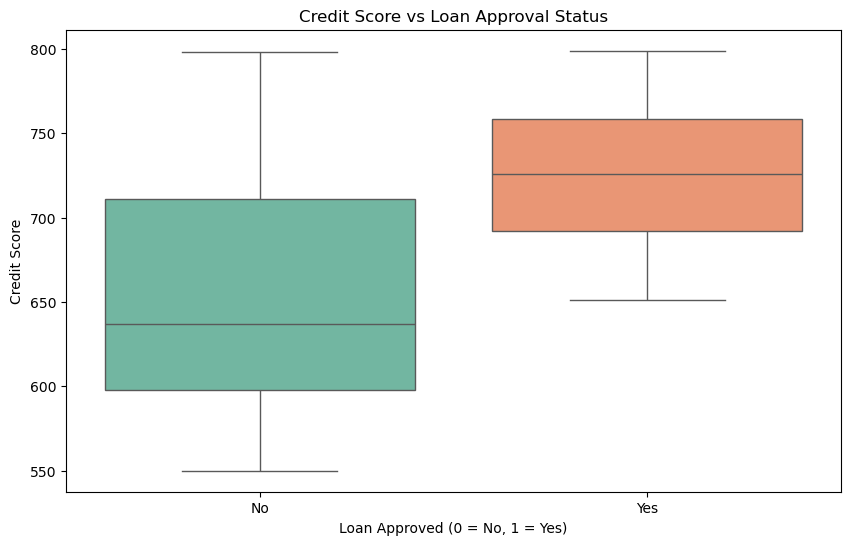

In [16]:
# From Correlation heatmap we observed that Loan_Approved status mainly depends on Credit_Score ----> A value of 0.47
# lets plot how it varies with credit_score 
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x="Loan_Approved", y="Credit_Score", palette="Set2",hue ="Loan_Approved")
plt.title("Credit Score vs Loan Approval Status")
plt.xlabel("Loan Approved (0 = No, 1 = Yes)")
plt.ylabel("Credit Score")
plt.show()

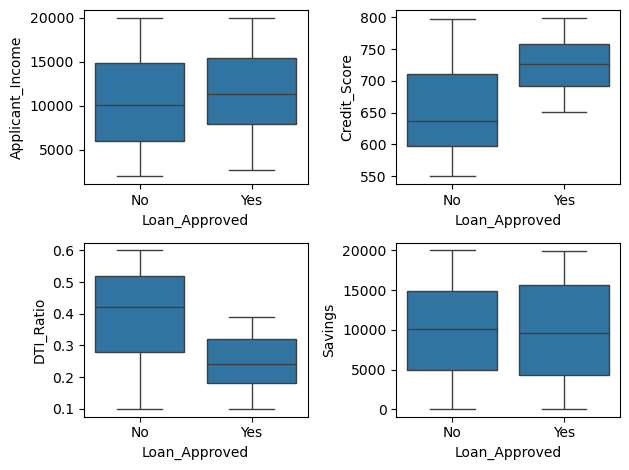

In [17]:
fig, axes = plt.subplots(2, 2)

sns.boxplot(ax=axes[0, 0], data=df, x="Loan_Approved",y="Applicant_Income")
sns.boxplot(ax=axes[0, 1], data=df, x="Loan_Approved",y="Credit_Score")
sns.boxplot(ax=axes[1, 0], data=df, x="Loan_Approved",y="DTI_Ratio")
sns.boxplot(ax=axes[1, 1], data=df, x="Loan_Approved",y="Savings")

plt.tight_layout()

<Axes: xlabel='Credit_Score', ylabel='Count'>

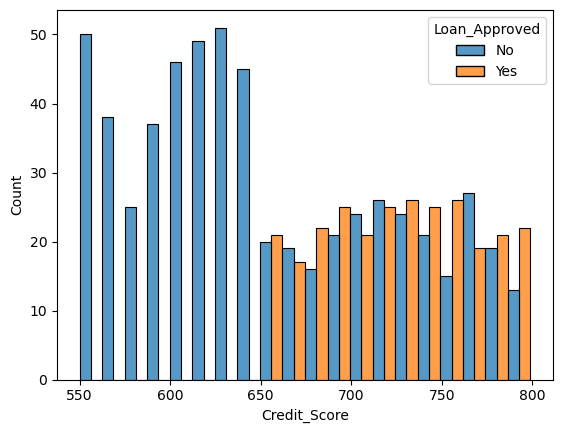

In [18]:
# Credit Score with Loan Approved

sns.histplot(
    data=df,
    x="Credit_Score",
    hue="Loan_Approved",
    bins=20,
    multiple="dodge"
)

<Axes: xlabel='Applicant_Income', ylabel='Count'>

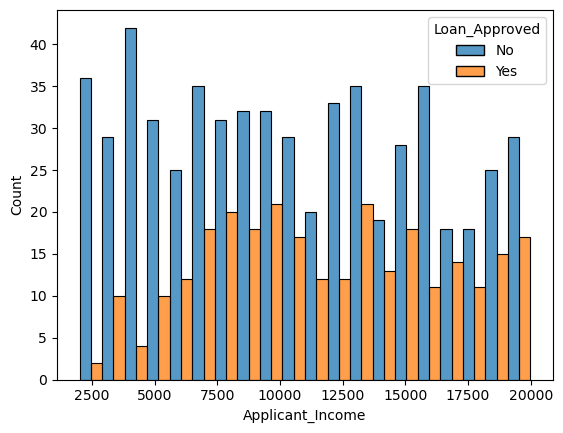

In [19]:
sns.histplot(
    data=df,
    x="Applicant_Income",
    hue="Loan_Approved",
    bins=20,
    multiple="dodge"
)

# Train-Test-Split + Feature Scaling + Encoding

In [20]:
# Step 1 — Manual mappings BEFORE split (no leakage risk, nothing learned)

df["Loan_Approved"] = df["Loan_Approved"].map({"Yes": 1, "No": 0})
df["Gender"] = df["Gender"].map({"Female": 0, "Male": 1})
df["Marital_Status"] = df["Marital_Status"].map({"Single": 0, "Married": 1})
df["Education_Level"] = df["Education_Level"].map({"Not Graduate": 0, "Graduate": 1})

# Step 2 — Define column groups
num_cols = ['Applicant_Income', 'Coapplicant_Income', 'Credit_Score', 
            'DTI_Ratio', 'Savings']  # your numeric cols

ohe_cols = ['Property_Area', 'Employment_Status', 
            'Loan_Purpose', 'Employer_Category']  # OHE cols

binary_cols = ['Gender', 'Marital_Status', 'Education_Level']  # already encoded

# Step 3 — Split FIRST
from sklearn.model_selection import train_test_split
X = df.drop("Loan_Approved", axis=1)
y = df["Loan_Approved"]
X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                    test_size=0.3, random_state=42, stratify=y)

# Step 4 — Build ColumnTransformer (handles impute + encode + scale together)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(drop='first', handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_cols),
    ('cat', cat_pipeline, ohe_cols),
    ('bin', SimpleImputer(strategy='most_frequent'), binary_cols)  # just impute, already encoded
])
# Step 5 — Plug into full model pipeline
from sklearn.dummy import DummyClassifier
full_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', DummyClassifier()) 
])

# Model Training and Evaluation

## 1. Logistic Regression

In [21]:
from sklearn.linear_model import LogisticRegression

full_pipeline.set_params(classifier=LogisticRegression())
full_pipeline.fit(X_train, y_train)
y_pred_logistic = full_pipeline.predict(X_test)

In [22]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

acc_score1 = accuracy_score(y_test,y_pred_logistic)
print(f"Accuracy_score for Logistic Regression :{acc_score1:.2f}\n")
print("Classification report:\n",classification_report(y_test,y_pred_logistic))

Accuracy_score for Logistic Regression :0.87

Classification report:
               precision    recall  f1-score   support

           0       0.89      0.93      0.91       185
           1       0.83      0.74      0.79        86

    accuracy                           0.87       271
   macro avg       0.86      0.84      0.85       271
weighted avg       0.87      0.87      0.87       271



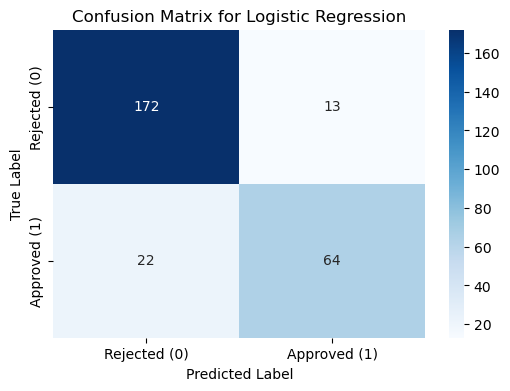

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

# Plotting the Confusion Matrix Heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_logistic), annot=True, fmt='d', cmap='Blues',
            xticklabels=['Rejected (0)', 'Approved (1)'],
            yticklabels=['Rejected (0)', 'Approved (1)'])

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Logistic Regression')
plt.show()

In [24]:
# type 1 errors -> 13
# type 2 errors - > 22

## 2.Naive Bayes

In [25]:
from sklearn.naive_bayes import GaussianNB

full_pipeline.set_params(classifier=GaussianNB())
full_pipeline.fit(X_train, y_train)
y_pred_NB = full_pipeline.predict(X_test)

In [26]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

acc_score2 = accuracy_score(y_test,y_pred_NB)
print(f"Accuracy_score for Naive Bayes Classifier :{acc_score2:.2f}\n")
print("Classification report:\n",classification_report(y_test,y_pred_NB))

Accuracy_score for Naive Bayes Classifier :0.86

Classification report:
               precision    recall  f1-score   support

           0       0.88      0.93      0.90       185
           1       0.83      0.72      0.77        86

    accuracy                           0.86       271
   macro avg       0.85      0.83      0.84       271
weighted avg       0.86      0.86      0.86       271



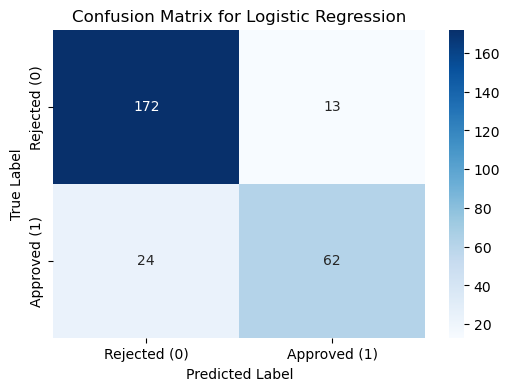

In [27]:
# Plotting the Confusion Matrix Heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_NB), annot=True, fmt='d', cmap='Blues',
            xticklabels=['Rejected (0)', 'Approved (1)'],
            yticklabels=['Rejected (0)', 'Approved (1)'])

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Logistic Regression')
plt.show()

## 3. KNN

In [28]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV

# GridSearchCV to find best K — pipeline handles scaling internally
param_grid = {'classifier__n_neighbors': [3, 4, 5, 6, 7, 8, 9]}

knn_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', KNeighborsClassifier())
])

G_CV = GridSearchCV(knn_pipeline, param_grid, cv=5, scoring='accuracy')
G_CV.fit(X_train, y_train)

# Best Parameters
print("Best Parameters:", G_CV.best_params_)
print(f"Best CV Accuracy: {G_CV.best_score_:.2f}")

# Best model predictions
y_pred_knn = G_CV.predict(X_test)
print(f"\nTest Accuracy for Tuned KNN: {accuracy_score(y_test, y_pred_knn):.2f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred_knn))

Best Parameters: {'classifier__n_neighbors': 9}
Best CV Accuracy: 0.87

Test Accuracy for Tuned KNN: 0.88

Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.91      0.91       185
           1       0.80      0.81      0.81        86

    accuracy                           0.88       271
   macro avg       0.86      0.86      0.86       271
weighted avg       0.88      0.88      0.88       271



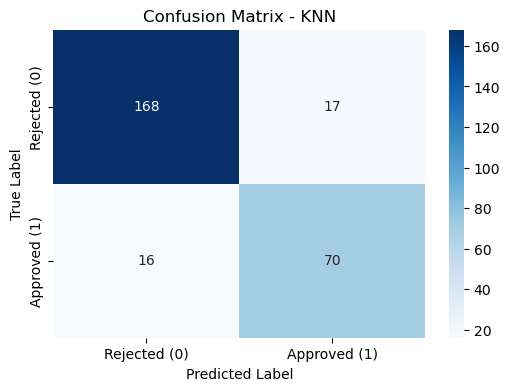

In [29]:
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_knn), annot=True, fmt='d', cmap='Blues',
            xticklabels=['Rejected (0)', 'Approved (1)'],
            yticklabels=['Rejected (0)', 'Approved (1)'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - KNN')
plt.show()

# 4. Decision Trees

## 4a.Without Pruning (Baseline)

In [30]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

# Unpruned tree — expect overfitting
full_pipeline.set_params(classifier=DecisionTreeClassifier(random_state=42))
full_pipeline.fit(X_train, y_train)
y_pred_dt = full_pipeline.predict(X_test)

train_score = full_pipeline.score(X_train, y_train)
test_score  = accuracy_score(y_test, y_pred_dt)

print(f"Training Accuracy (Unpruned): {train_score:.2f}")
print(f"Test Accuracy     (Unpruned): {test_score:.2f}  <-- overfitting  gap is large")
print("\nClassification Report:\n", classification_report(y_test, y_pred_dt))

Training Accuracy (Unpruned): 1.00
Test Accuracy     (Unpruned): 0.92  <-- overfitting  gap is large

Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.92      0.94       185
           1       0.84      0.92      0.88        86

    accuracy                           0.92       271
   macro avg       0.90      0.92      0.91       271
weighted avg       0.92      0.92      0.92       271



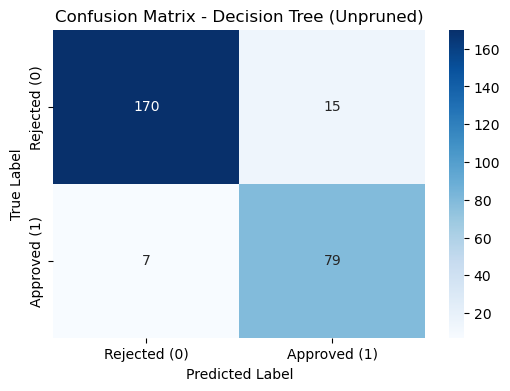

In [31]:
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_dt), annot=True, fmt='d', cmap='Blues',
            xticklabels=['Rejected (0)', 'Approved (1)'],
            yticklabels=['Rejected (0)', 'Approved (1)'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - Decision Tree (Unpruned)')
plt.show()

## 4b. Pre-Pruning (max_depth + min_samples_leaf)

depth=2  |  train=0.93  |  test=0.91
depth=3  |  train=0.96  |  test=0.93
depth=4  |  train=0.96  |  test=0.93
depth=5  |  train=0.96  |  test=0.93
depth=6  |  train=0.97  |  test=0.92
depth=7  |  train=0.98  |  test=0.91
depth=8  |  train=0.98  |  test=0.92
depth=9  |  train=0.99  |  test=0.91
depth=10  |  train=1.00  |  test=0.92


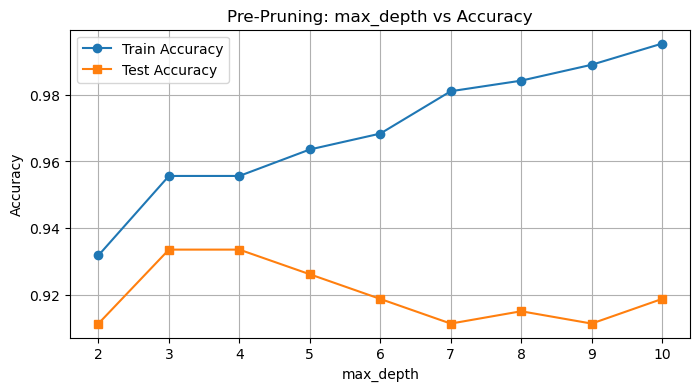

In [32]:
# Finding best max_depth
train_scores = []
test_scores  = []
depths = [2, 3, 4, 5, 6, 7, 8, 9, 10]

for depth in depths:
    full_pipeline.set_params(classifier=DecisionTreeClassifier(max_depth=depth, random_state=42))
    full_pipeline.fit(X_train, y_train)
    train_scores.append(full_pipeline.score(X_train, y_train))
    test_scores.append(full_pipeline.score(X_test, y_test))
    print(f"depth={depth}  |  train={train_scores[-1]:.2f}  |  test={test_scores[-1]:.2f}")

# Plot depth vs accuracy
plt.figure(figsize=(8, 4))
plt.plot(depths, train_scores, marker='o', label='Train Accuracy')
plt.plot(depths, test_scores,  marker='s', label='Test Accuracy')
plt.xlabel('max_depth')
plt.ylabel('Accuracy')
plt.title('Pre-Pruning: max_depth vs Accuracy')
plt.legend()
plt.grid(True)
plt.show()

In [33]:
# Best pre-pruned model (adjust max_depth based on plot above)
full_pipeline.set_params(classifier=DecisionTreeClassifier(
    max_depth=5,
    min_samples_leaf=15,
    min_samples_split=10,
    random_state=42
))
full_pipeline.fit(X_train, y_train)
y_pred_dt_pre = full_pipeline.predict(X_test)

print(f"Training Accuracy (Pre-Pruned): {full_pipeline.score(X_train, y_train):.2f}")
print(f"Test Accuracy     (Pre-Pruned): {accuracy_score(y_test, y_pred_dt_pre):.2f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred_dt_pre))

Training Accuracy (Pre-Pruned): 0.96
Test Accuracy     (Pre-Pruned): 0.93

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.92      0.95       185
           1       0.85      0.97      0.90        86

    accuracy                           0.93       271
   macro avg       0.91      0.94      0.93       271
weighted avg       0.94      0.93      0.93       271



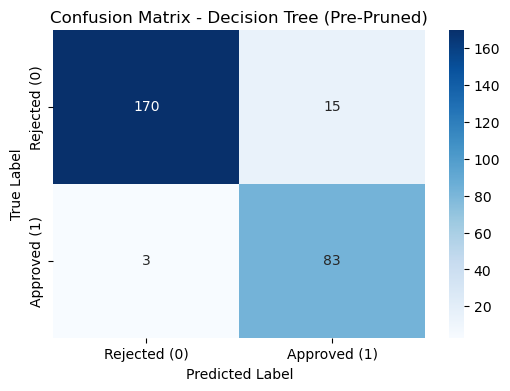

In [34]:
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_dt_pre), annot=True, fmt='d', cmap='Blues',
            xticklabels=['Rejected (0)', 'Approved (1)'],
            yticklabels=['Rejected (0)', 'Approved (1)'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - Decision Tree (Pre-Pruned)')
plt.show()

##  4c. Post-Pruning (Cost Complexity Pruning — ccp_alpha)

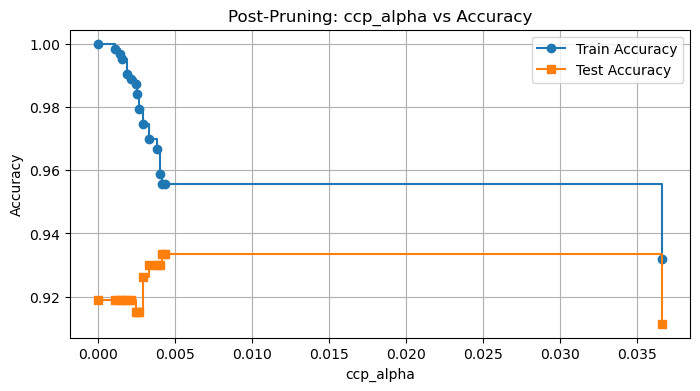

In [35]:
# Find best ccp_alpha — transform train data first to get alpha path
X_train_transformed = preprocessor.fit_transform(X_train, y_train)

temp_tree = DecisionTreeClassifier(random_state=42)
path = temp_tree.cost_complexity_pruning_path(X_train_transformed, y_train)
ccp_alphas = path.ccp_alphas[:-1]  # remove last (trivial empty tree)

# Test each alpha
train_scores_ccp, test_scores_ccp = [], []
for alpha in ccp_alphas:
    full_pipeline.set_params(classifier=DecisionTreeClassifier(ccp_alpha=alpha, random_state=42))
    full_pipeline.fit(X_train, y_train)
    train_scores_ccp.append(full_pipeline.score(X_train, y_train))
    test_scores_ccp.append(full_pipeline.score(X_test, y_test))

# Plot alpha vs accuracy
plt.figure(figsize=(8, 4))
plt.plot(ccp_alphas, train_scores_ccp, marker='o', label='Train Accuracy', drawstyle='steps-post')
plt.plot(ccp_alphas, test_scores_ccp,  marker='s', label='Test Accuracy',  drawstyle='steps-post')
plt.xlabel('ccp_alpha')
plt.ylabel('Accuracy')
plt.title('Post-Pruning: ccp_alpha vs Accuracy')
plt.legend()
plt.grid(True)
plt.show()

In [36]:
# Best alpha = where test accuracy is highest
best_alpha = ccp_alphas[test_scores_ccp.index(max(test_scores_ccp))]
print(f"Best ccp_alpha: {best_alpha:.4f}")

full_pipeline.set_params(classifier=DecisionTreeClassifier(ccp_alpha=best_alpha, random_state=42))
full_pipeline.fit(X_train, y_train)
y_pred_dt_post = full_pipeline.predict(X_test)

print(f"Training Accuracy (Post-Pruned): {full_pipeline.score(X_train, y_train):.2f}")
print(f"Test Accuracy     (Post-Pruned): {accuracy_score(y_test, y_pred_dt_post):.2f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred_dt_post))

Best ccp_alpha: 0.0041
Training Accuracy (Post-Pruned): 0.96
Test Accuracy     (Post-Pruned): 0.93

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.92      0.95       185
           1       0.85      0.97      0.90        86

    accuracy                           0.93       271
   macro avg       0.91      0.94      0.93       271
weighted avg       0.94      0.93      0.93       271



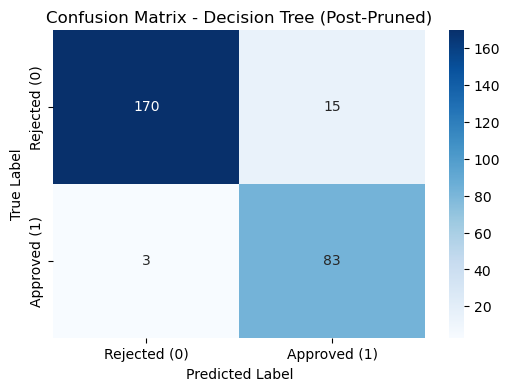

In [37]:
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_dt_post), annot=True, fmt='d', cmap='Blues',
            xticklabels=['Rejected (0)', 'Approved (1)'],
            yticklabels=['Rejected (0)', 'Approved (1)'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - Decision Tree (Post-Pruned)')
plt.show()

## 4d.Feature Importance

C:\Users\Prasanth\AppData\Local\Temp\ipykernel_20540\3517787115.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feat_imp_df, x='Importance', y='Feature', palette='Blues_r')


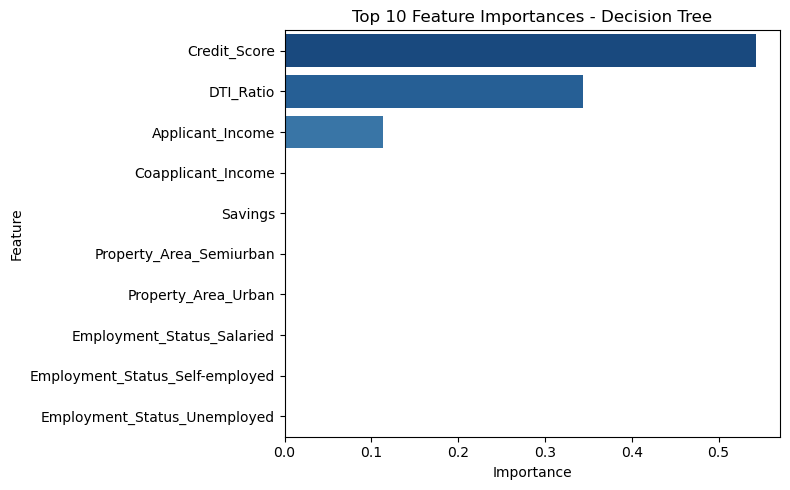

In [38]:
# Get feature names after preprocessing
ohe_feature_names = (preprocessor
                     .named_transformers_['cat']
                     .named_steps['encoder']
                     .get_feature_names_out(ohe_cols).tolist())

all_feature_names = num_cols + ohe_feature_names + binary_cols

# Feature importances from post-pruned DT
dt_model = full_pipeline.named_steps['classifier']
feat_imp_df = pd.DataFrame({'Feature': all_feature_names, 'Importance': dt_model.feature_importances_})
feat_imp_df = feat_imp_df.sort_values('Importance', ascending=False).head(10)

plt.figure(figsize=(8, 5))
sns.barplot(data=feat_imp_df, x='Importance', y='Feature', palette='Blues_r')
plt.title('Top 10 Feature Importances - Decision Tree')
plt.tight_layout()
plt.show()

# 5.SVC

In [39]:
from sklearn.svm import SVC

full_pipeline.set_params(classifier=SVC(kernel='rbf', probability=True, random_state=42))
full_pipeline.fit(X_train, y_train)
y_pred_svc = full_pipeline.predict(X_test)

print(f"Accuracy Score for SVC: {accuracy_score(y_test, y_pred_svc):.2f}\n")
print("Classification Report:\n", classification_report(y_test, y_pred_svc))

Accuracy Score for SVC: 0.89

Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.92      0.92       185
           1       0.83      0.84      0.83        86

    accuracy                           0.89       271
   macro avg       0.88      0.88      0.88       271
weighted avg       0.89      0.89      0.89       271



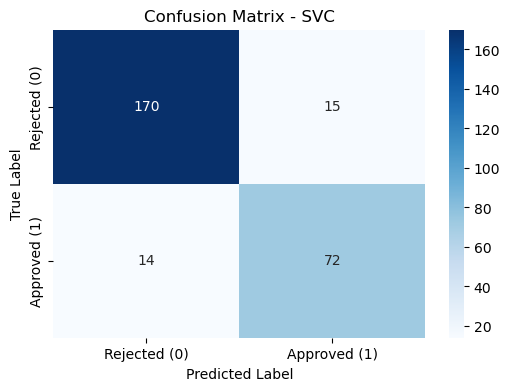

In [40]:
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_svc), annot=True, fmt='d', cmap='Blues',
            xticklabels=['Rejected (0)', 'Approved (1)'],
            yticklabels=['Rejected (0)', 'Approved (1)'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - SVC')
plt.show()

# 6.Random Forest

In [41]:
from sklearn.ensemble import RandomForestClassifier

full_pipeline.set_params(classifier=RandomForestClassifier(n_estimators=100, random_state=42))
full_pipeline.fit(X_train, y_train)
y_pred_rf = full_pipeline.predict(X_test)

print(f"Accuracy Score for Random Forest: {accuracy_score(y_test, y_pred_rf):.2f}\n")
print("Classification Report:\n", classification_report(y_test, y_pred_rf))

Accuracy Score for Random Forest: 0.93

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.92      0.94       185
           1       0.85      0.93      0.89        86

    accuracy                           0.93       271
   macro avg       0.91      0.93      0.92       271
weighted avg       0.93      0.93      0.93       271



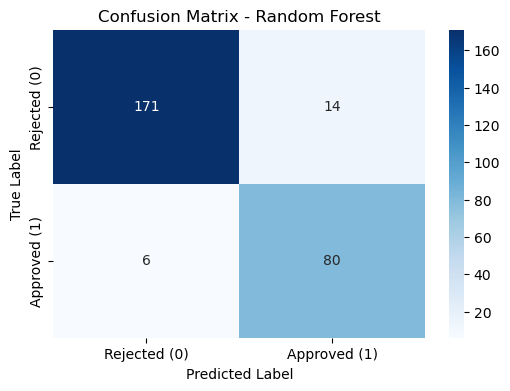

In [42]:
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d', cmap='Blues',
            xticklabels=['Rejected (0)', 'Approved (1)'],
            yticklabels=['Rejected (0)', 'Approved (1)'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - Random Forest')
plt.show()

C:\Users\Prasanth\AppData\Local\Temp\ipykernel_20540\1773801734.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feat_imp_rf, x='Importance', y='Feature', palette='Greens_r')


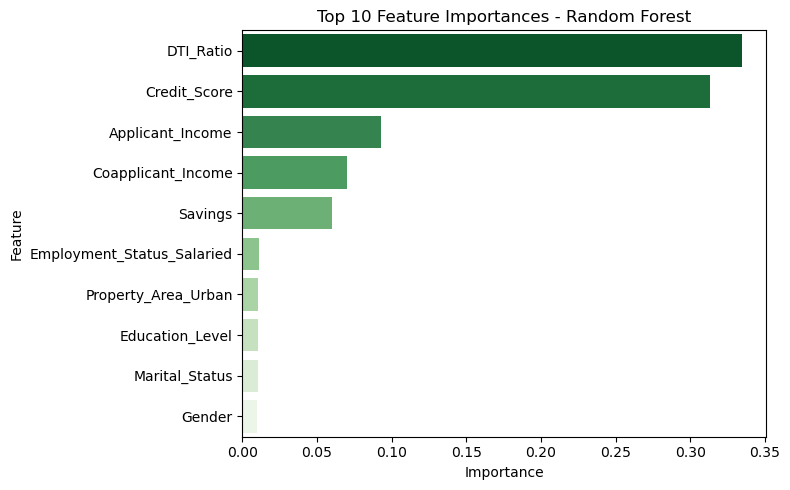

In [43]:
# Feature Importance - Random Forest
rf_model = full_pipeline.named_steps['classifier']
feat_imp_rf = pd.DataFrame({'Feature': all_feature_names, 'Importance': rf_model.feature_importances_})
feat_imp_rf = feat_imp_rf.sort_values('Importance', ascending=False).head(10)

plt.figure(figsize=(8, 5))
sns.barplot(data=feat_imp_rf, x='Importance', y='Feature', palette='Greens_r')
plt.title('Top 10 Feature Importances - Random Forest')
plt.tight_layout()
plt.show()

# 7. Gradient Boosting

In [44]:
from sklearn.ensemble import GradientBoostingClassifier

full_pipeline.set_params(classifier=GradientBoostingClassifier(n_estimators=100, random_state=42))
full_pipeline.fit(X_train, y_train)
y_pred_gb = full_pipeline.predict(X_test)

print(f"Accuracy Score for Gradient Boosting: {accuracy_score(y_test, y_pred_gb):.2f}\n")
print("Classification Report:\n", classification_report(y_test, y_pred_gb))

Accuracy Score for Gradient Boosting: 0.94

Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.91      0.95       185
           1       0.84      0.99      0.91        86

    accuracy                           0.94       271
   macro avg       0.92      0.95      0.93       271
weighted avg       0.95      0.94      0.94       271



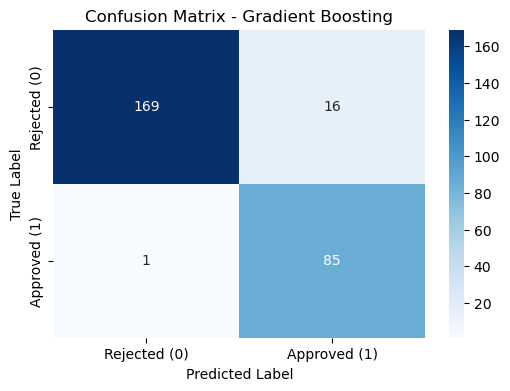

In [45]:
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_gb), annot=True, fmt='d', cmap='Blues',
            xticklabels=['Rejected (0)', 'Approved (1)'],
            yticklabels=['Rejected (0)', 'Approved (1)'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - Gradient Boosting')
plt.show()

# 8.Adaboost

In [46]:
from sklearn.ensemble import AdaBoostClassifier

full_pipeline.set_params(classifier=AdaBoostClassifier(n_estimators=100, random_state=42))
full_pipeline.fit(X_train, y_train)
y_pred_ada = full_pipeline.predict(X_test)

print(f"Accuracy Score for AdaBoost: {accuracy_score(y_test, y_pred_ada):.2f}\n")
print("Classification Report:\n", classification_report(y_test, y_pred_ada))

Accuracy Score for AdaBoost: 0.94

Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.92      0.95       185
           1       0.85      0.98      0.91        86

    accuracy                           0.94       271
   macro avg       0.92      0.95      0.93       271
weighted avg       0.94      0.94      0.94       271



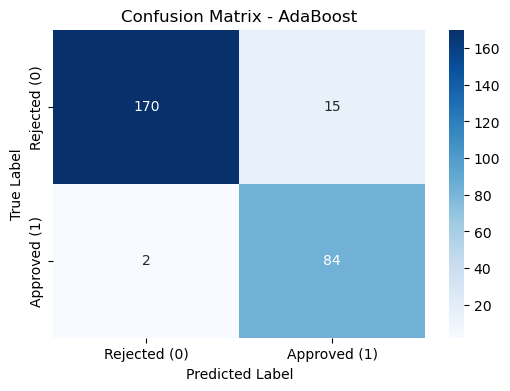

In [47]:
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_ada), annot=True, fmt='d', cmap='Blues',
            xticklabels=['Rejected (0)', 'Approved (1)'],
            yticklabels=['Rejected (0)', 'Approved (1)'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - AdaBoost')
plt.show()

# 9.XGBoost

In [48]:
from xgboost import XGBClassifier

full_pipeline.set_params(classifier=XGBClassifier(
    n_estimators=100,
    random_state=42,
    eval_metric='logloss',
    verbosity=0
))
full_pipeline.fit(X_train, y_train)
y_pred_xgb = full_pipeline.predict(X_test)

print(f"Accuracy Score for XGBoost: {accuracy_score(y_test, y_pred_xgb):.2f}\n")
print("Classification Report:\n", classification_report(y_test, y_pred_xgb))

Accuracy Score for XGBoost: 0.91

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.91      0.93       185
           1       0.83      0.91      0.87        86

    accuracy                           0.91       271
   macro avg       0.89      0.91      0.90       271
weighted avg       0.92      0.91      0.91       271



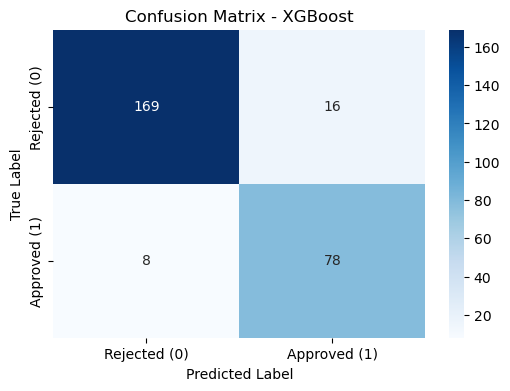

In [49]:
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_xgb), annot=True, fmt='d', cmap='Blues',
            xticklabels=['Rejected (0)', 'Approved (1)'],
            yticklabels=['Rejected (0)', 'Approved (1)'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - XGBoost')
plt.show()

## Model Performance Comparison

In [50]:
from sklearn.metrics import roc_auc_score, f1_score

model_classes = {
    'Logistic Regression': LogisticRegression(max_iter=500),
    'Naive Bayes':         GaussianNB(),
    'KNN':                 KNeighborsClassifier(n_neighbors=G_CV.best_params_['classifier__n_neighbors']),
    'Decision Tree':       DecisionTreeClassifier(ccp_alpha=best_alpha, random_state=42),
    'SVC':                 SVC(kernel='rbf', probability=True, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting':   GradientBoostingClassifier(n_estimators=100, random_state=42),
    'AdaBoost':            AdaBoostClassifier(n_estimators=100, random_state=42),
    'XGBoost':             XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss', verbosity=0),
}

results = []
for name, clf in model_classes.items():
    pipe = Pipeline([('preprocessor', preprocessor), ('classifier', clf)])
    pipe.fit(X_train, y_train)
    y_pred  = pipe.predict(X_test)
    y_prob  = pipe.predict_proba(X_test)[:, 1]
    results.append({
        'Model':    name,
        'Accuracy': round(accuracy_score(y_test, y_pred), 3),
        'F1 Score': round(f1_score(y_test, y_pred, average='weighted'), 3),
        'ROC-AUC':  round(roc_auc_score(y_test, y_prob), 3)
    })

results_df = pd.DataFrame(results).sort_values('ROC-AUC', ascending=False).reset_index(drop=True)
print(results_df.to_string(index=False))

              Model  Accuracy  F1 Score  ROC-AUC
           AdaBoost     0.937     0.938    0.980
  Gradient Boosting     0.937     0.938    0.980
            XGBoost     0.911     0.912    0.980
      Random Forest     0.926     0.927    0.973
      Decision Tree     0.934     0.935    0.971
                SVC     0.893     0.893    0.964
                KNN     0.878     0.878    0.952
        Naive Bayes     0.863     0.861    0.949
Logistic Regression     0.871     0.869    0.938


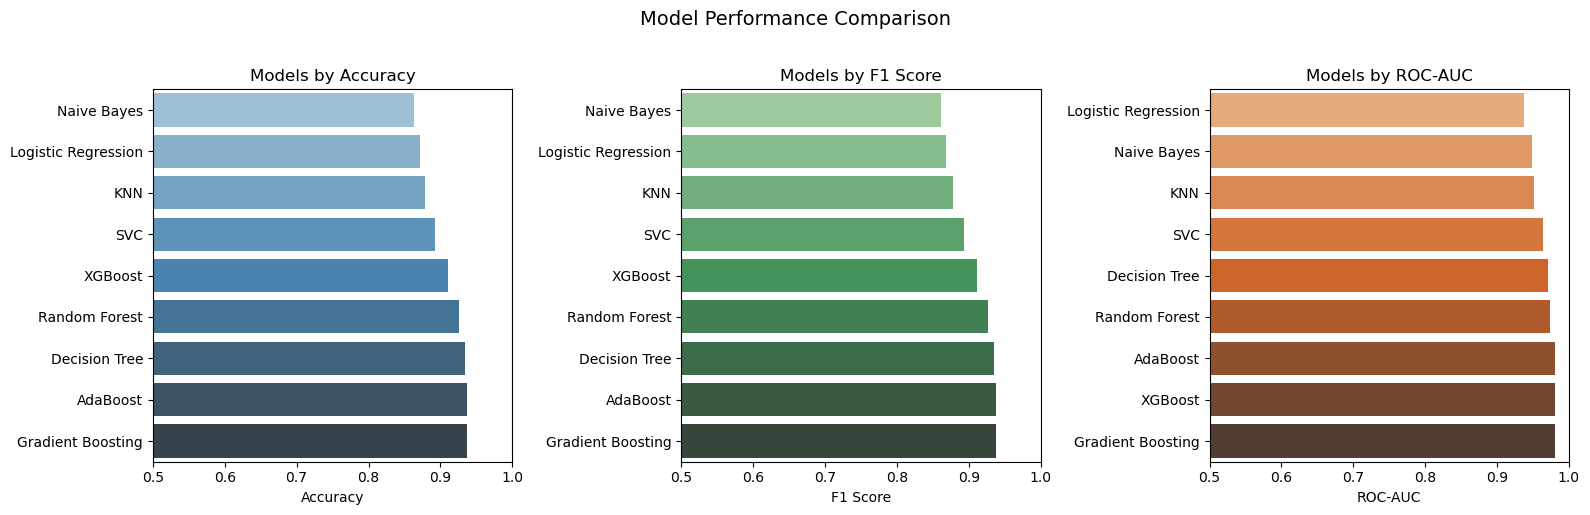

In [51]:
# Visual comparison
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

metrics = ['Accuracy', 'F1 Score', 'ROC-AUC']
colors  = ['Blues_d', 'Greens_d', 'Oranges_d']

for ax, metric, color in zip(axes, metrics, colors):
    sorted_df = results_df.sort_values(metric, ascending=True)
    sns.barplot(data=sorted_df, x=metric, y='Model', hue='Model', palette=color, legend=False, ax=ax)
    ax.set_title(f'Models by {metric}')
    ax.set_xlim(0.5, 1.0)
    ax.set_xlabel(metric)
    ax.set_ylabel('')

plt.suptitle('Model Performance Comparison', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## Prediction Function

In [52]:
# Best model — automatically picked from performance table
best_model_name = results_df.iloc[0]['Model']
print(f"Best Model: {best_model_name}")

best_clf  = model_classes[best_model_name]
best_pipe = Pipeline([('preprocessor', preprocessor), ('classifier', best_clf)])
best_pipe.fit(X_train, y_train)

def predict_loan_approval(applicant_details: dict):
    """
    Predicts loan approval for a single applicant.

    Parameters:
        applicant_details (dict): feature values for one applicant

    Returns:
        (prediction, probability) tuple

    Example input:
        {
            'Applicant_ID': 1001,
            'Gender': 1,               # 1=Male, 0=Female
            'Marital_Status': 1,       # 1=Married, 0=Single
            'Education_Level': 1,      # 1=Graduate, 0=Not Graduate
            'Applicant_Income': 5000,
            'Coapplicant_Income': 2000,
            'Credit_Score': 720,
            'DTI_Ratio': 0.3,
            'Savings': 15000,
            'Property_Area': 'Urban',
            'Employment_Status': 'Full-Time',
            'Loan_Purpose': 'Home',
            'Employer_Category': 'Private'
        }
    """
    input_df = pd.DataFrame([applicant_details])
    prediction  = best_pipe.predict(input_df)[0]
    probability = best_pipe.predict_proba(input_df)[0][1]

    status = "APPROVED" if prediction == 1 else "REJECTED"
    print(f"Loan Decision       : {status}")
    print(f"Approval Probability: {probability:.2%}")
    return prediction, probability


# --- Test ---
predict_loan_approval({
    'Applicant_ID': 1001,
    'Gender': 1,
    'Marital_Status': 1,
    'Education_Level': 1,
    'Applicant_Income': 6000,
    'Coapplicant_Income': 2000,
    'Credit_Score': 750,
    'DTI_Ratio': 0.25,
    'Savings': 20000,
    'Property_Area': 'Urban',
    'Employment_Status': 'Full-Time',
    'Loan_Purpose': 'Home',
    'Employer_Category': 'Private'
})

Best Model: AdaBoost
Loan Decision       : APPROVED
Approval Probability: 57.01%


C:\Users\Prasanth\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
C:\Users\Prasanth\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


(np.int64(1), np.float64(0.5700984464773343))